# 03. Card-Level Behavior

## Goal

The goal of this notebook is to compare known business and consumer cards at the card level.

## Why this matters

The final goal is not to classify individual transactions, but to identify consumer cards with business-like behavior. A single transaction is usually not enough to understand whether a card is used for commercial activity.

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
# pd.options.display.float_format = "{:,.4f}".format

from mdq.data import load_data
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
business, consumer, merchant, mcc = load_data()

In [3]:
merchants_no_mcc = merchant.drop(columns=["mcc"])

mcc_ref = mcc[["mcc", "mcc_name"]].copy()
mcc_ref["mcc"] = mcc_ref["mcc"].astype(str).str.zfill(4)

business_txn = business.copy()
consumer_txn = consumer.copy()

business_txn["segment"] = "business"
consumer_txn["segment"] = "consumer"

for df in [business_txn, consumer_txn]:
    df["mcc"] = df["mcc"].astype(str).str.zfill(4)

business_txn = business_txn.merge(
    merchants_no_mcc,
    on="merchant_id",
    how="left",
    validate="many_to_one"
).merge(
    mcc_ref,
    on="mcc",
    how="left",
    validate="many_to_one"
)

consumer_txn = consumer_txn.merge(
    merchants_no_mcc,
    on="merchant_id",
    how="left",
    validate="many_to_one"
).merge(
    mcc_ref,
    on="mcc",
    how="left",
    validate="many_to_one"
)

In [4]:
for df in [business_txn, consumer_txn]:
    mask = (df["merchant_id"] == "MER_000000") & (df["mcc"] == "7012")

    df.loc[mask, "merchant_id"] = "MER_000000_MCC_7012_placeholder"
    df.loc[mask, "merchant_name"] = "MER_000000 / MCC 7012 placeholder"

In [5]:
for df in [business_txn, consumer_txn]:
    df["ts"] = pd.to_datetime(df["transaction_timestamp"])
    df["hour"] = df["ts"].dt.hour
    df["dow"] = df["ts"].dt.dayofweek
    df["month"] = df["ts"].dt.to_period("M").astype(str)

    df["is_weekend"] = df["dow"] >= 5
    df["weekday_business_hours"] = (df["dow"] < 5) & df["hour"].between(9, 18)
    df["weekday_non_business_hours"] = (df["dow"] < 5) & ~df["hour"].between(9, 18)

In [6]:
biz_txn_count = business_txn.groupby("card_number").size()
con_txn_count = consumer_txn.groupby("card_number").size()

pd.DataFrame({
    "business": biz_txn_count.describe(),
    "consumer": con_txn_count.describe(),
})

,business,consumer
count,25000.000000,80000.000000
mean,119.903720,122.906087
std,43.044349,47.978862
min,26.000000,17.000000
25%,84.000000,85.000000
50%,119.000000,120.000000
75%,155.000000,156.000000
max,242.000000,354.000000


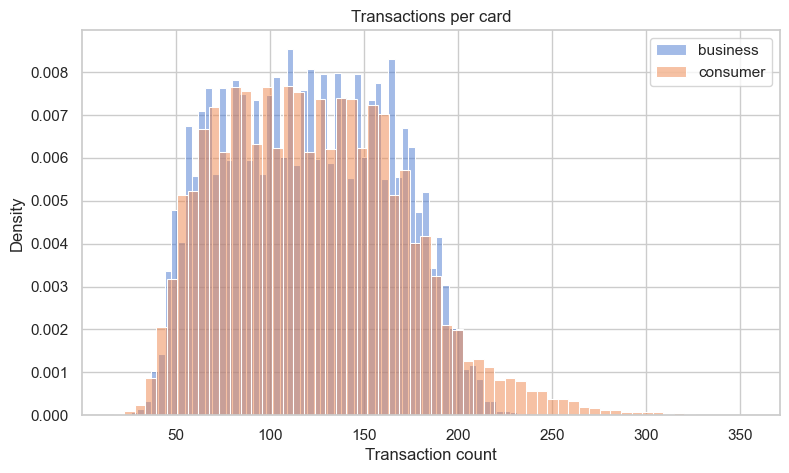

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(biz_txn_count, bins=60, stat="density", label="business", alpha=0.5)
sns.histplot(con_txn_count, bins=60, stat="density", label="consumer", alpha=0.5)
plt.title("Transactions per card")
plt.xlabel("Transaction count")
plt.legend()
plt.show()

### Transactions per card

**Observation.** The number of transactions per card looks very similar for business and consumer cards. The mean and median values are almost the same, and the two distributions overlap a lot.

Consumer cards also have a longer right tail, meaning that some consumer cards are even more active than most business cards.

In [8]:
pd.options.display.float_format = "{:,.4f}".format
biz_total_spend = business_txn.groupby("card_number")["transaction_amount_kzt"].sum()
con_total_spend = consumer_txn.groupby("card_number")["transaction_amount_kzt"].sum()

pd.DataFrame({
    "business": biz_total_spend.describe(),
    "consumer": con_total_spend.describe(),
})

,business,consumer
count,"25,000.0000","80,000.0000"
mean,"18,769,161.7454","6,642,511.7084"
std,"6,897,552.6051","8,606,654.9232"
min,"2,615,035.0000","345,287.0000"
25%,"13,637,012.7500","1,966,989.2500"
50%,"17,714,892.5000","2,976,294.0000"
75%,"22,885,893.0000","6,259,915.7500"
max,"64,357,034.0000","170,159,026.0000"


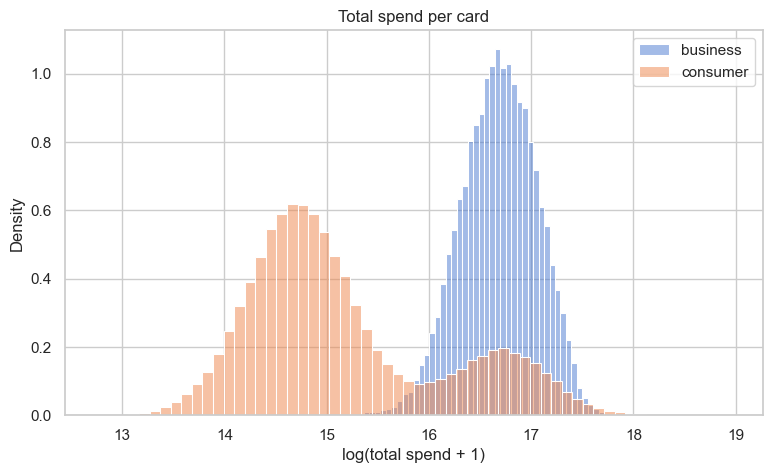

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(np.log1p(biz_total_spend), bins=60, stat="density", label="business", alpha=0.5)
sns.histplot(np.log1p(con_total_spend), bins=60, stat="density", label="consumer", alpha=0.5)
plt.title("Total spend per card")
plt.xlabel("log(total spend + 1)")
plt.legend()
plt.show()

### Total spend per card

**Observation.** Total spend per card is much higher for business cards. The business distribution is clearly shifted to the right, while most consumer cards are in the lower spend range.

At the same time, there is a smaller group of consumer cards with high total spend, closer to the business range. So high spending is not only a business behavior, some consumers can also spend a lot.

**Feature idea.** This supports creating a `total_spend` feature, because it captures the total turnover of a card during the whole period.

For modeling, we can use `log_total_spend` instead of the raw value, because spending values have large differences and the log version makes the feature more stable.

In [10]:
biz_avg_amount = business_txn.groupby("card_number")["transaction_amount_kzt"].mean()
con_avg_amount = consumer_txn.groupby("card_number")["transaction_amount_kzt"].mean()

biz_median_amount = business_txn.groupby("card_number")["transaction_amount_kzt"].median()
con_median_amount = consumer_txn.groupby("card_number")["transaction_amount_kzt"].median()

pd.DataFrame({
    "business_avg": biz_avg_amount.describe(),
    "consumer_avg": con_avg_amount.describe(),
    "business_median": biz_median_amount.describe(),
    "consumer_median": con_median_amount.describe(),
})

,business_avg,consumer_avg,business_median,consumer_median
count,"25,000.0000","80,000.0000","25,000.0000","80,000.0000"
mean,"167,642.4478","54,770.1359","92,225.2454","23,119.4511"
std,"64,423.2617","71,239.4984","50,852.4894","37,855.8825"
min,"26,838.9255","5,446.9939","2,116.0000","2,134.0000"
25%,"125,838.9315","17,147.4727","59,458.6250","5,919.0000"
50%,"155,609.8994","26,774.9452","84,558.5000","9,673.5000"
75%,"193,926.9268","63,565.2793","115,733.3750","26,389.0000"
max,"776,261.3333","2,215,909.5455","612,595.5000","1,520,916.0000"


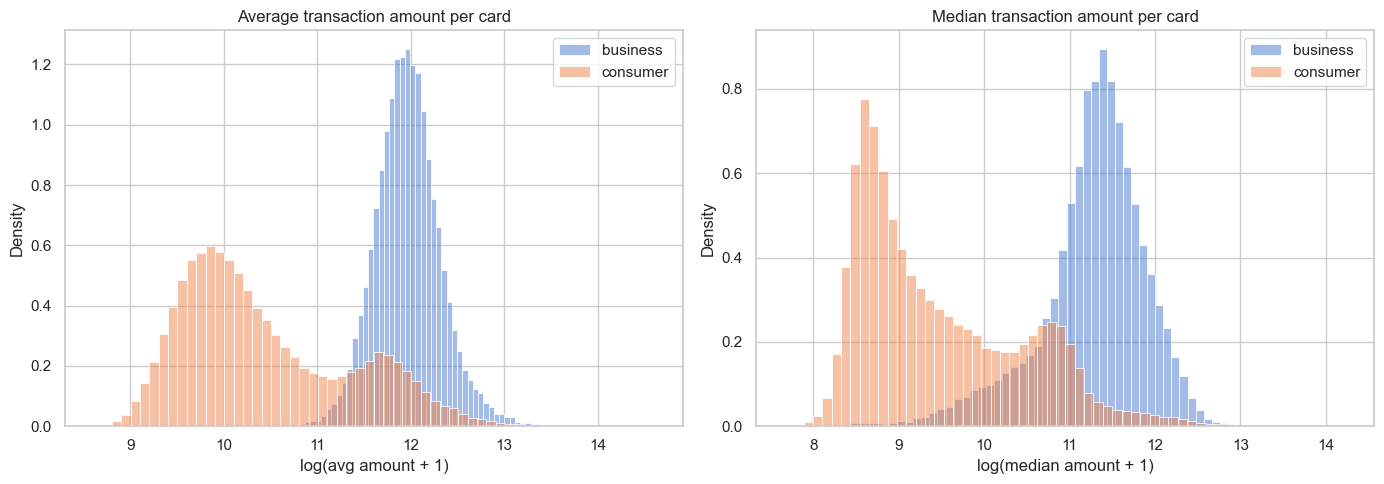

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(np.log1p(biz_avg_amount), bins=60, stat="density", label="business", alpha=0.5, ax=axes[0])
sns.histplot(np.log1p(con_avg_amount), bins=60, stat="density", label="consumer", alpha=0.5, ax=axes[0])
axes[0].set_title("Average transaction amount per card")
axes[0].set_xlabel("log(avg amount + 1)")
axes[0].legend()

sns.histplot(np.log1p(biz_median_amount), bins=60, stat="density", label="business", alpha=0.5, ax=axes[1])
sns.histplot(np.log1p(con_median_amount), bins=60, stat="density", label="consumer", alpha=0.5, ax=axes[1])
axes[1].set_title("Median transaction amount per card")
axes[1].set_xlabel("log(median amount + 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Average and median transaction amount per card

**Observation.** Business cards have higher average and median transaction amounts compared to consumer cards. The distributions are shifted to the right for both features.

The median amount is especially useful here because it is less affected by a few very large transactions. Since the business median is also higher, the difference is not only coming from outliers.

There is still some overlap, so a high transaction amount does not automatically mean business activity.

**Feature idea.** This supports creating `avg_transaction_amount` and `median_transaction_amount` as card-level monetary features.

For modeling, we can use log-transformed versions like `log_avg_transaction_amount` and `log_median_transaction_amount`, because transaction amounts can have large differences between cards.

`median_transaction_amount` can be more stable than the average, because it describes a typical payment size and is less sensitive to extreme transactions. We can also later create an `avg_to_median_ratio` feature to capture cards where a few large payments make the average much higher than the median.

In [12]:
thresholds = [10_000, 50_000, 100_000, 500_000]

rows = []

for t in thresholds:
    biz_ratio = business_txn.groupby("card_number")["transaction_amount_kzt"].apply(lambda s: (s >= t).mean())
    con_ratio = consumer_txn.groupby("card_number")["transaction_amount_kzt"].apply(lambda s: (s >= t).mean())

    rows.append({
        "threshold": t,
        "business_median": biz_ratio.median(),
        "consumer_median": con_ratio.median(),
        "business_mean": biz_ratio.mean(),
        "consumer_mean": con_ratio.mean(),
    })

large_ticket_card = pd.DataFrame(rows)
large_ticket_card

,threshold,business_median,consumer_median,business_mean,consumer_mean
0,10000,0.8857,0.4909,0.8551,0.5464
1,50000,0.6333,0.1287,0.6220,0.2152
2,100000,0.4557,0.0549,0.4630,0.1196
3,500000,0.0604,0.0000,0.0721,0.0172


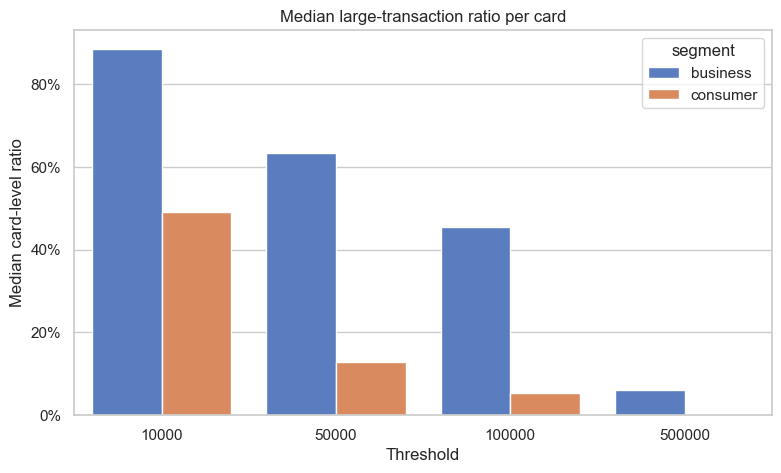

In [13]:
plot_df = large_ticket_card.melt(
    id_vars="threshold",
    value_vars=["business_median", "consumer_median"],
    var_name="segment",
    value_name="median_ratio"
)

plot_df["segment"] = plot_df["segment"].str.replace("_median", "")

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="threshold", y="median_ratio", hue="segment")
plt.title("Median large-transaction ratio per card")
plt.xlabel("Threshold")
plt.ylabel("Median card-level ratio")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Average and median transaction amount per card

**Observation.** Business cards have higher average and median transaction amounts compared to consumer cards. The distributions are shifted to the right for both features.

The median amount is especially useful here because it is less affected by a few very large transactions. Since the business median is also higher, the difference is not only coming from outliers.

There is still some overlap, so a high transaction amount does not automatically mean business activity.

**Feature idea.** This supports creating `log_avg_transaction_amount` and `log_median_transaction_amount` as card-level monetary features.

`log_avg_transaction_amount` captures the average payment size of a card, while `log_median_transaction_amount` describes a more typical payment size. The median can be more stable because it is less sensitive to rare large transactions.

We can also later create an `avg_to_median_ratio` feature to capture cards where a few large payments make the average much higher than the median.

In [14]:
pd.options.display.float_format = "{:,.4f}".format
biz_online_ratio = business_txn.groupby("card_number")["channel"].apply(lambda s: (s == "online").mean())
con_online_ratio = consumer_txn.groupby("card_number")["channel"].apply(lambda s: (s == "online").mean())

pd.DataFrame({
    "business": biz_online_ratio.describe(),
    "consumer": con_online_ratio.describe(),
})

,business,consumer
count,"25,000.0000","80,000.0000"
mean,0.8484,0.4687
std,0.0502,0.1015
min,0.5455,0.1915
25%,0.8203,0.4056
50%,0.8525,0.4472
75%,0.8817,0.5024
max,1.0000,1.0000


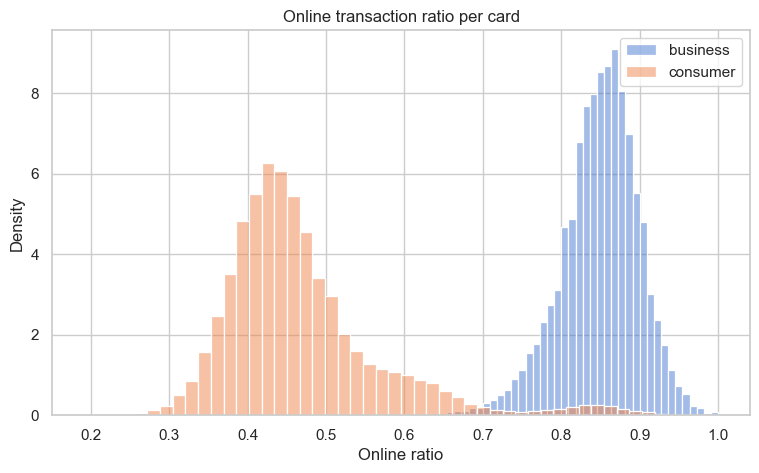

In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(biz_online_ratio, bins=50, stat="density", label="business", alpha=0.5)
sns.histplot(con_online_ratio, bins=50, stat="density", label="consumer", alpha=0.5)
plt.title("Online transaction ratio per card")
plt.xlabel("Online ratio")
plt.legend()
plt.show()

### Online transaction ratio per card

**Observation.** Business cards have a much higher online transaction ratio compared to consumer cards. Most business cards are concentrated around 0.8–0.9, while consumer cards are mostly around 0.4–0.5.

This matches the merchant-level analysis, where business cards were more connected with online services like ads, SaaS, cloud, hosting and business tools. Consumer cards look more balanced between online and offline usage.

**Feature idea.** This supports creating an `online_ratio` feature at the card level.

This feature can be useful because many business-related payments happen online, especially ads, cloud services, SaaS tools and e-commerce platforms. But online usage alone is not enough, because normal consumers can also shop online a lot. It becomes more meaningful when combined with MCC groups and merchant categories.

In [32]:
pd.options.display.float_format = "{:,.7f}".format
biz_recurring_ratio = business_txn.groupby("card_number")["is_recurring"].mean()
con_recurring_ratio = consumer_txn.groupby("card_number")["is_recurring"].mean()

biz_tokenized_ratio = business_txn.groupby("card_number")["tokenized"].mean()
con_tokenized_ratio = consumer_txn.groupby("card_number")["tokenized"].mean()

biz_recurring_capable_ratio = business_txn.groupby("card_number")["recurring_capable"].mean()
con_recurring_capable_ratio = consumer_txn.groupby("card_number")["recurring_capable"].mean()

pd.DataFrame({
    "business_recurring": biz_recurring_ratio.describe(),
    "consumer_recurring": con_recurring_ratio.describe(),
    "business_tokenized": biz_tokenized_ratio.describe(),
    "consumer_tokenized": con_tokenized_ratio.describe(),
    "business_recurring_capable": biz_recurring_capable_ratio.describe(),
    "consumer_recurring_capable": con_recurring_capable_ratio.describe(),
})

,business_recurring,consumer_recurring,business_tokenized,consumer_tokenized,business_recurring_capable,consumer_recurring_capable
count,"25,000.0000000","80,000.0000000","25,000.0000000","80,000.0000000","25,000.0000000","80,000.0000000"
mean,0.1547003,0.0314208,0.5845689,0.3847803,0.3362625,0.0740161
std,0.0756818,0.0433036,0.0683919,0.0506870,0.1726517,0.1446653
min,0.0000000,0.0000000,0.2368421,0.1000000,0.0000000,0.0000000
25%,0.1028571,0.0000000,0.5468750,0.3533333,0.2045455,0.0000000
50%,0.1343284,0.0000000,0.5949367,0.3855422,0.2941176,0.0321101
75%,0.1914894,0.0508475,0.6319583,0.4166667,0.4509804,0.0812500
max,0.5454545,0.4864865,0.8695652,0.6750000,0.9142857,1.0000000


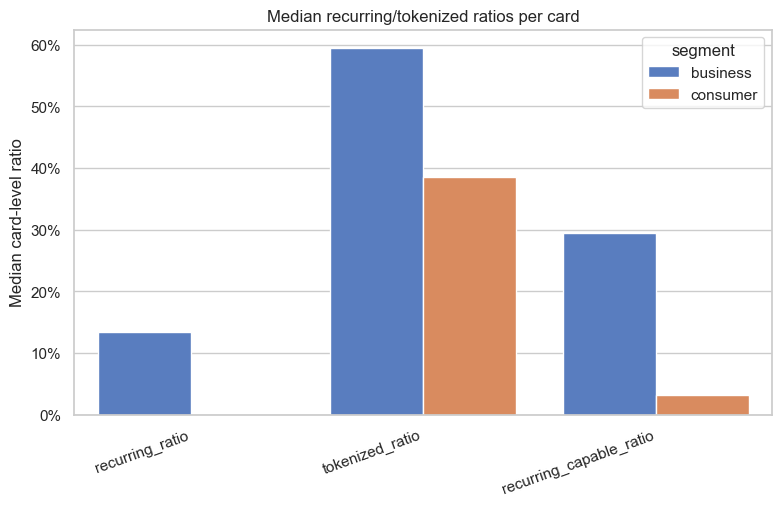

In [33]:
ratio_summary = pd.DataFrame({
    "business": [
        biz_recurring_ratio.median(),
        biz_tokenized_ratio.median(),
        biz_recurring_capable_ratio.median(),
    ],
    "consumer": [
        con_recurring_ratio.median(),
        con_tokenized_ratio.median(),
        con_recurring_capable_ratio.median(),
    ],
}, index=["recurring_ratio", "tokenized_ratio", "recurring_capable_ratio"])

plot_df = ratio_summary.reset_index(names="metric").melt(
    id_vars="metric",
    var_name="segment",
    value_name="median_ratio"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="median_ratio", hue="segment")
plt.title("Median recurring/tokenized ratios per card")
plt.xlabel("")
plt.ylabel("Median card-level ratio")
plt.xticks(rotation=20, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Recurring, tokenized and recurring-capable ratios per card

**Observation.** Business cards have higher median values for all three ratios. The strongest difference is visible in `recurring_capable_ratio`, where business cards are much higher than consumer cards.

`recurring_ratio` is also higher for business cards, while the median consumer value is close to zero. This suggests that regular payments are more common in business behavior.

`tokenized_ratio` is higher for business cards too, but this is more of a usage pattern than a direct business signal.

**Feature idea.** This supports creating `recurring_ratio`, `recurring_capable_ratio` and `tokenized_ratio` as card-level behavioral features.

`recurring_ratio` can capture actual repeated payments, such as subscriptions or auto-billing. `recurring_capable_ratio` is useful because it shows how often the card interacts with merchants that can support recurring payments, even if the exact transaction is not marked as recurring.

`tokenized_ratio` should be treated more carefully. It can help describe how the card is used, but by itself it does not prove business activity. It is more useful when combined with online ratio, MCC groups and merchant categories.

In [18]:
time_cols = ["weekday_business_hours", "weekday_non_business_hours", "is_weekend"]

biz_card_time = business_txn.groupby("card_number")[time_cols].mean()
con_card_time = consumer_txn.groupby("card_number")[time_cols].mean()

pd.DataFrame({
    "business_median": biz_card_time.median(),
    "consumer_median": con_card_time.median(),
    "business_mean": biz_card_time.mean(),
    "consumer_mean": con_card_time.mean(),
})

,business_median,consumer_median,business_mean,consumer_mean
weekday_business_hours,0.642857,0.394737,0.630430,0.401319
weekday_non_business_hours,0.231579,0.252475,0.240500,0.253456
is_weekend,0.124138,0.350230,0.129070,0.345226


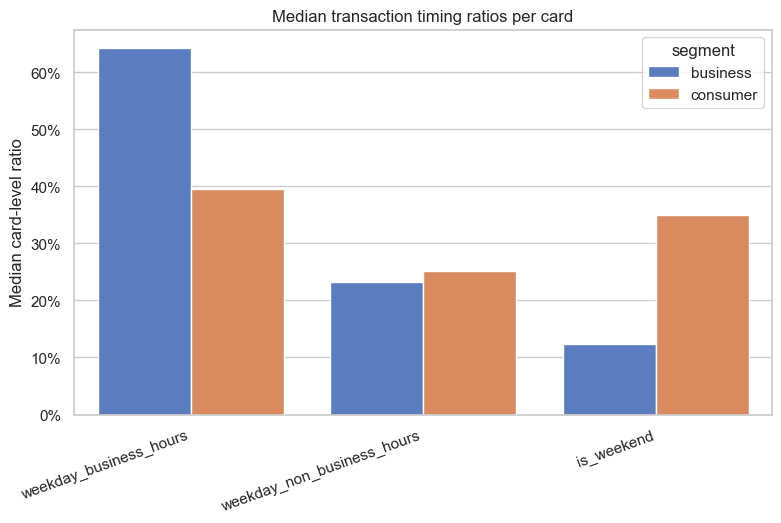

In [19]:
time_summary = pd.concat([
    biz_card_time.median().rename("business"),
    con_card_time.median().rename("consumer"),
], axis=1)

plot_df = time_summary.reset_index(names="time_bucket").melt(
    id_vars="time_bucket",
    var_name="segment",
    value_name="median_ratio"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="time_bucket", y="median_ratio", hue="segment")
plt.title("Median transaction timing ratios per card")
plt.xlabel("")
plt.ylabel("Median card-level ratio")
plt.xticks(rotation=20, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.show()

### Transaction timing ratios per card

**Observation.** Business cards have a higher share of transactions during weekday business hours. The median value is around 64% for business cards and around 39% for consumer cards.

Consumer cards have a higher weekend ratio. This suggests that consumer spending is more often shifted to weekends, while business cards are more concentrated during regular working days.

For weekday non-business hours, the difference is small, so this part does not look like a strong separator by itself.

**Feature idea.** This supports creating `weekday_business_hours_ratio`, `weekday_non_business_hours_ratio` and `weekend_ratio` as card-level timing features.

`weekday_business_hours_ratio` can help capture cards that are used more like an operational business tool during working hours. `weekend_ratio` can describe more personal spending patterns, but it should not be used as a strict rule.

In [20]:
biz_unique_merchants = business_txn.groupby("card_number")["merchant_id"].nunique()
con_unique_merchants = consumer_txn.groupby("card_number")["merchant_id"].nunique()

pd.DataFrame({
    "business": biz_unique_merchants.describe(),
    "consumer": con_unique_merchants.describe(),
})

,business,consumer
count,"25,000.000000","80,000.000000"
mean,17.142480,36.752525
std,6.546441,14.203196
min,4.000000,2.000000
25%,12.000000,28.000000
50%,16.000000,37.000000
75%,21.000000,47.000000
max,49.000000,95.000000


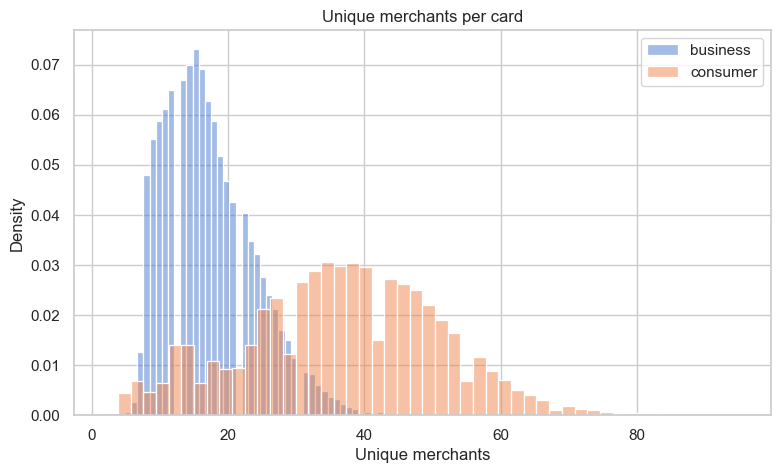

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(biz_unique_merchants, bins=50, stat="density", label="business", alpha=0.5)
sns.histplot(con_unique_merchants, bins=50, stat="density", label="consumer", alpha=0.5)
plt.title("Unique merchants per card")
plt.xlabel("Unique merchants")
plt.legend()
plt.show()

### Transaction timing ratios per card

**Observation.** Business cards have a higher share of transactions during weekday business hours. The median value is around 64% for business cards and around 39% for consumer cards.

Consumer cards have a higher weekend ratio. This suggests that consumer spending is more often shifted to weekends, while business cards are more concentrated during regular working days.

For weekday non-business hours, the difference is small, so this part does not look like a strong separator by itself.

**Feature idea.** This supports creating `weekday_business_hours_ratio`, `weekday_non_business_hours_ratio` and `weekend_ratio` as card-level timing features.

`weekday_business_hours_ratio` can help capture cards that are used more like an operational business tool during working hours. `weekend_ratio` can describe more personal spending patterns, but it should not be used as a strict rule.

These timing features are not enough alone, but they can add useful context when combined with total spend, online ratio, MCC groups and merchant behavior.

In [22]:
biz_unique_mcc = business_txn.groupby("card_number")["mcc"].nunique()
con_unique_mcc = consumer_txn.groupby("card_number")["mcc"].nunique()

pd.DataFrame({
    "business": biz_unique_mcc.describe(),
    "consumer": con_unique_mcc.describe(),
})

,business,consumer
count,"25,000.000000","80,000.000000"
mean,14.848760,31.682800
std,4.037541,11.227422
min,4.000000,2.000000
25%,12.000000,24.000000
50%,15.000000,32.000000
75%,18.000000,40.000000
max,28.000000,64.000000


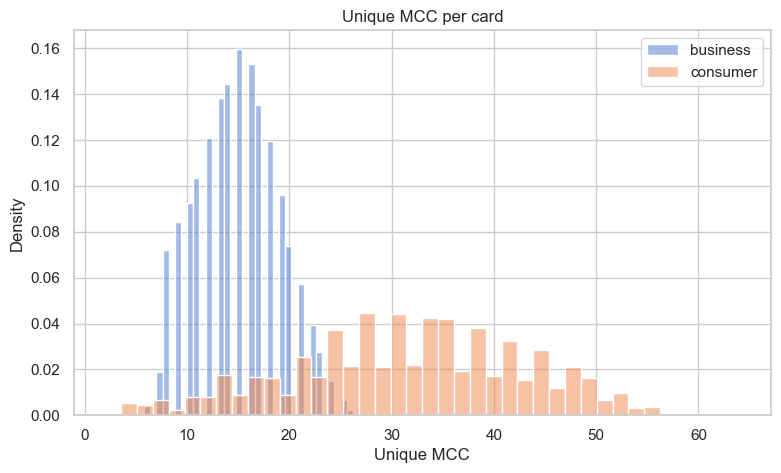

In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(biz_unique_mcc, bins=40, stat="density", label="business", alpha=0.5)
sns.histplot(con_unique_mcc, bins=40, stat="density", label="consumer", alpha=0.5)
plt.title("Unique MCC per card")
plt.xlabel("Unique MCC")
plt.legend()
plt.show()

### Unique MCC per card

**Observation.** Consumer cards have more unique MCC categories per card than business cards. The consumer distribution is shifted to the right, while business cards are more concentrated in a smaller number of MCCs.

This means that higher MCC diversity does not automatically mean more business-like behavior. In this dataset, consumer cards look more diverse by category, probably because personal spending covers many daily-life categories.

**Feature idea.** This supports creating `unique_mcc_count` as a card-level feature, but we should not interpret it as “higher means more business”.

For this task, the type of MCC is probably more important than only the number of MCCs. In the final feature set, `unique_mcc_count` should be combined with category-based features like `ads_mcc_ratio`, `cloud_saas_mcc_ratio`, `business_mcc_ratio`, and `top_mcc_share`.

In [24]:
def entropy_from_counts(counts):
    probs = counts / counts.sum()
    return -(probs * np.log(probs)).sum()


def entropy_per_card(df, col):
    return (
        df.groupby("card_number")[col]
        .value_counts()
        .groupby(level=0)
        .apply(entropy_from_counts)
    )

In [25]:
biz_merchant_entropy = entropy_per_card(business_txn, "merchant_id")
con_merchant_entropy = entropy_per_card(consumer_txn, "merchant_id")

biz_mcc_entropy = entropy_per_card(business_txn, "mcc")
con_mcc_entropy = entropy_per_card(consumer_txn, "mcc")

pd.DataFrame({
    "business_merchant_entropy": biz_merchant_entropy.describe(),
    "consumer_merchant_entropy": con_merchant_entropy.describe(),
    "business_mcc_entropy": biz_mcc_entropy.describe(),
    "consumer_mcc_entropy": con_mcc_entropy.describe(),
})

,business_merchant_entropy,consumer_merchant_entropy,business_mcc_entropy,consumer_mcc_entropy
count,"25,000.000000","80,000.000000","25,000.000000","80,000.000000"
mean,2.104552,3.164064,2.064206,3.037426
std,0.284636,0.638539,0.244495,0.588502
min,0.963508,0.114665,0.963508,0.114665
25%,1.909716,3.066202,1.897944,2.935012
50%,2.096234,3.346114,2.073067,3.199838
75%,2.285543,3.563599,2.234038,3.413836
max,3.445362,4.257687,2.894068,3.903512


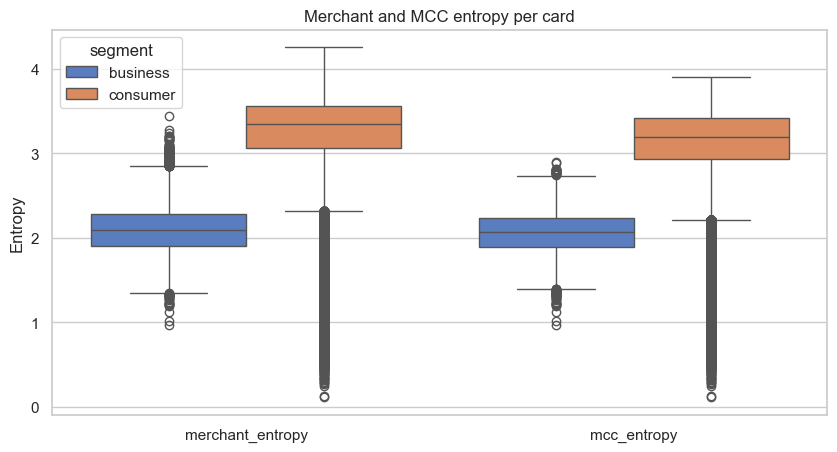

In [26]:
entropy_df = pd.concat([
    pd.DataFrame({"segment": "business", "metric": "merchant_entropy", "value": biz_merchant_entropy}),
    pd.DataFrame({"segment": "consumer", "metric": "merchant_entropy", "value": con_merchant_entropy}),
    pd.DataFrame({"segment": "business", "metric": "mcc_entropy", "value": biz_mcc_entropy}),
    pd.DataFrame({"segment": "consumer", "metric": "mcc_entropy", "value": con_mcc_entropy}),
])

plt.figure(figsize=(10, 5))
sns.boxplot(data=entropy_df, x="metric", y="value", hue="segment")
plt.title("Merchant and MCC entropy per card")
plt.xlabel("")
plt.ylabel("Entropy")
plt.show()

### Merchant and MCC entropy per card

**Observation.** Consumer cards have higher merchant and MCC entropy than business cards. This means consumer spending is more evenly spread across different merchants and categories.

Business cards are more concentrated. This matches the previous results, where business cards were mostly connected with ads, cloud, SaaS, hosting and other work-related services.

**Feature idea.** This supports creating `merchant_entropy` and `mcc_entropy` as card-level behavior features.

These features are useful because they describe how concentrated or diverse the card behavior is. However, entropy alone does not tell us whether the card is business-like. It only shows the structure of spending.

For modeling, entropy should be combined with features like `top_mcc_share`, `top_merchant_share`, `ads_mcc_ratio`, `cloud_saas_ratio` and other merchant group features. This helps separate active consumers with broad daily spending from cards that are more focused on business-related services.

In [27]:
B2B_MCC_GROUPS = {
    "advertising": ["7311"],
    "software_cloud": ["7372"],
    "business_services": ["7399", "7392"],
    "office_supplies": ["5943", "5111"],
    "telecom": ["4814", "4816"],
    "logistics": ["4214", "4215", "4225"],
    "professional_services": ["8111", "8931", "8999"],
}

In [28]:
rows = []

for group, codes in B2B_MCC_GROUPS.items():
    biz_ratio = business_txn.groupby("card_number")["mcc"].apply(lambda s: s.isin(codes).mean())
    con_ratio = consumer_txn.groupby("card_number")["mcc"].apply(lambda s: s.isin(codes).mean())

    rows.append({
        "group": group,
        "business_median": biz_ratio.median(),
        "consumer_median": con_ratio.median(),
        "business_mean": biz_ratio.mean(),
        "consumer_mean": con_ratio.mean(),
    })

b2b_card_exposure = pd.DataFrame(rows)
b2b_card_exposure

,group,business_median,consumer_median,business_mean,consumer_mean
0,advertising,0.072165,0.000000,0.095375,0.028460
1,software_cloud,0.063830,0.000000,0.083674,0.005271
2,business_services,0.025000,0.000000,0.065593,0.001868
3,office_supplies,0.009434,0.000000,0.045157,0.001975
4,telecom,0.067164,0.041916,0.096450,0.050704
5,logistics,0.021739,0.000000,0.062913,0.005036
6,professional_services,0.000000,0.000000,0.031539,0.001157


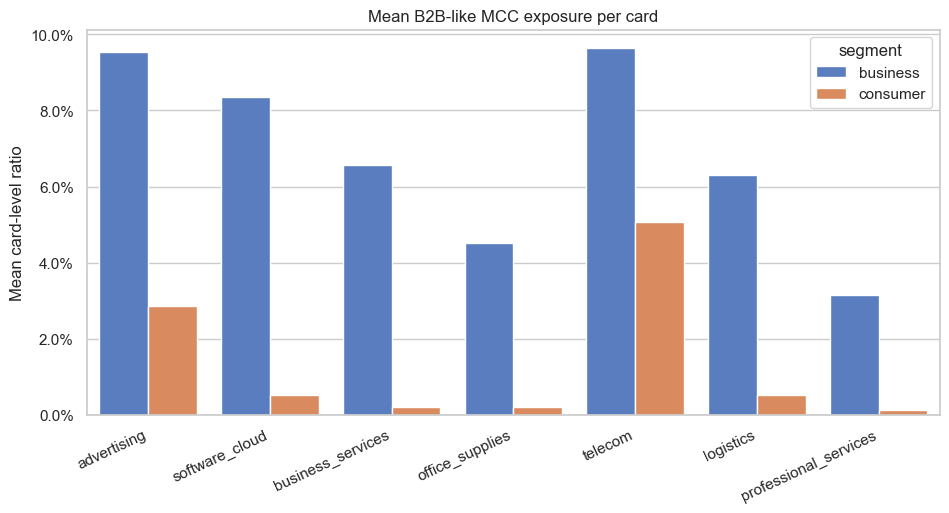

In [29]:
plot_df = b2b_card_exposure.melt(
    id_vars="group",
    value_vars=["business_mean", "consumer_mean"],
    var_name="segment",
    value_name="mean_ratio"
)

plot_df["segment"] = plot_df["segment"].str.replace("_mean", "")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="group", y="mean_ratio", hue="segment")
plt.title("Mean B2B-like MCC exposure per card")
plt.xlabel("")
plt.ylabel("Mean card-level ratio")
plt.xticks(rotation=25, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.show()

**Feature idea.** These MCC group ratios are strong candidates for the final feature set because they describe business-related spending categories, not just general activity.

However, we should validate their usefulness during modeling. Some groups, like advertising or software/cloud, are likely to be stronger signals, while others, like telecom, may be weaker because they are also common for consumers.

In the modeling step, we will compare models with and without these MCC group features and check both metrics and feature importance.

In [30]:
card_level_summary = pd.DataFrame({
    "business_median": {
        "txn_count": biz_txn_count.median(),
        "total_spend": biz_total_spend.median(),
        "avg_amount": biz_avg_amount.median(),
        "online_ratio": biz_online_ratio.median(),
        "recurring_ratio": biz_recurring_ratio.median(),
        "weekend_ratio": biz_card_time["is_weekend"].median(),
        "weekday_business_hours_ratio": biz_card_time["weekday_business_hours"].median(),
        "unique_merchants": biz_unique_merchants.median(),
        "unique_mcc": biz_unique_mcc.median(),
        "merchant_entropy": biz_merchant_entropy.median(),
        "mcc_entropy": biz_mcc_entropy.median(),
    },
    "consumer_median": {
        "txn_count": con_txn_count.median(),
        "total_spend": con_total_spend.median(),
        "avg_amount": con_avg_amount.median(),
        "online_ratio": con_online_ratio.median(),
        "recurring_ratio": con_recurring_ratio.median(),
        "weekend_ratio": con_card_time["is_weekend"].median(),
        "weekday_business_hours_ratio": con_card_time["weekday_business_hours"].median(),
        "unique_merchants": con_unique_merchants.median(),
        "unique_mcc": con_unique_mcc.median(),
        "merchant_entropy": con_merchant_entropy.median(),
        "mcc_entropy": con_mcc_entropy.median(),
    }
})

card_level_summary

,business_median,consumer_median
txn_count,119.000000,120.000000
total_spend,"17,714,892.500000","2,976,294.000000"
avg_amount,"155,609.899373","26,774.945242"
online_ratio,0.852459,0.447154
recurring_ratio,0.134328,0.000000
weekend_ratio,0.124138,0.350230
weekday_business_hours_ratio,0.642857,0.394737
unique_merchants,16.000000,37.000000
unique_mcc,15.000000,32.000000
merchant_entropy,2.096234,3.346114


## Card-Level Summary

This notebook compared business and consumer behavior at the card level, where one observation is one `card_number`.

The main purpose was to verify whether transaction-level differences remain visible after aggregation to full card profiles. They do: business and consumer cards differ across spend size, transaction composition, timing, merchant/MCC diversity, and exposure to B2B-like MCC groups.

Key signal groups identified for later feature engineering:

- spend level: total spend, average/median transaction amount, large-transaction ratios;
- channel and payment behavior: online ratio, recurring ratio, tokenized ratio, recurring-capable merchant ratio;
- timing behavior: weekday business-hours ratio, weekday non-business-hours ratio, weekend ratio;
- concentration/diversity: unique merchants, unique MCCs, merchant entropy, MCC entropy;
- commercial category exposure: B2B-like MCC group ratios.

The detailed numeric findings and interpretation are documented in `docs/eda_findings.md`. The next step is to consolidate these observations into a reproducible card-level feature table for modeling.

In [37]:
from pathlib import Path

FIG_PATH = Path("/Users/sapuantalaspay/vs_projects/data/EDA")

B2B_MCC_GROUPS = {
    "advertising": ["7311"],
    "software_cloud": ["7372"],
    "business_services": ["7399", "7392"],
    "office_supplies": ["5943", "5111"],
    "telecom": ["4814", "4816"],
    "logistics": ["4214", "4215", "4225"],
    "professional_services": ["8111", "8931", "8999"],
}

B2B_CODES = set(code for codes in B2B_MCC_GROUPS.values() for code in codes)


def hhi_per_card(df, col):
    def hhi(values):
        shares = values.value_counts(normalize=True)
        return (shares ** 2).sum()

    return df.groupby("card_number")[col].apply(hhi)


def build_viz_features(df):
    g = df.groupby("card_number")

    out = pd.DataFrame({
        "txn_count": g.size(),
        "total_spend": g["transaction_amount_kzt"].sum(),
        "avg_amount": g["transaction_amount_kzt"].mean(),
        "online_ratio": g["channel"].apply(lambda s: s.str.lower().eq("online").mean()),
        "recurring_ratio": g["is_recurring"].mean(),
        "business_hours_ratio": g["weekday_business_hours"].mean(),
        "weekday_ratio": g["dow"].apply(lambda s: (s < 5).mean()),
        "unique_merchants": g["merchant_id"].nunique(),
        "unique_mcc": g["mcc"].nunique(),
        "large_txn_100k_ratio": g["transaction_amount_kzt"].apply(lambda s: (s >= 100_000).mean()),
        "business_mcc_ratio": g["mcc"].apply(lambda s: s.isin(B2B_CODES).mean()),
    })

    out["mcc_hhi"] = hhi_per_card(df, "mcc")

    return out.reset_index()


business_card_viz = build_viz_features(business_txn)
consumer_card_viz = build_viz_features(consumer_txn)

business_card_viz["segment"] = "Business"
consumer_card_viz["segment"] = "Consumer"

viz_df = pd.concat([business_card_viz, consumer_card_viz], ignore_index=True)

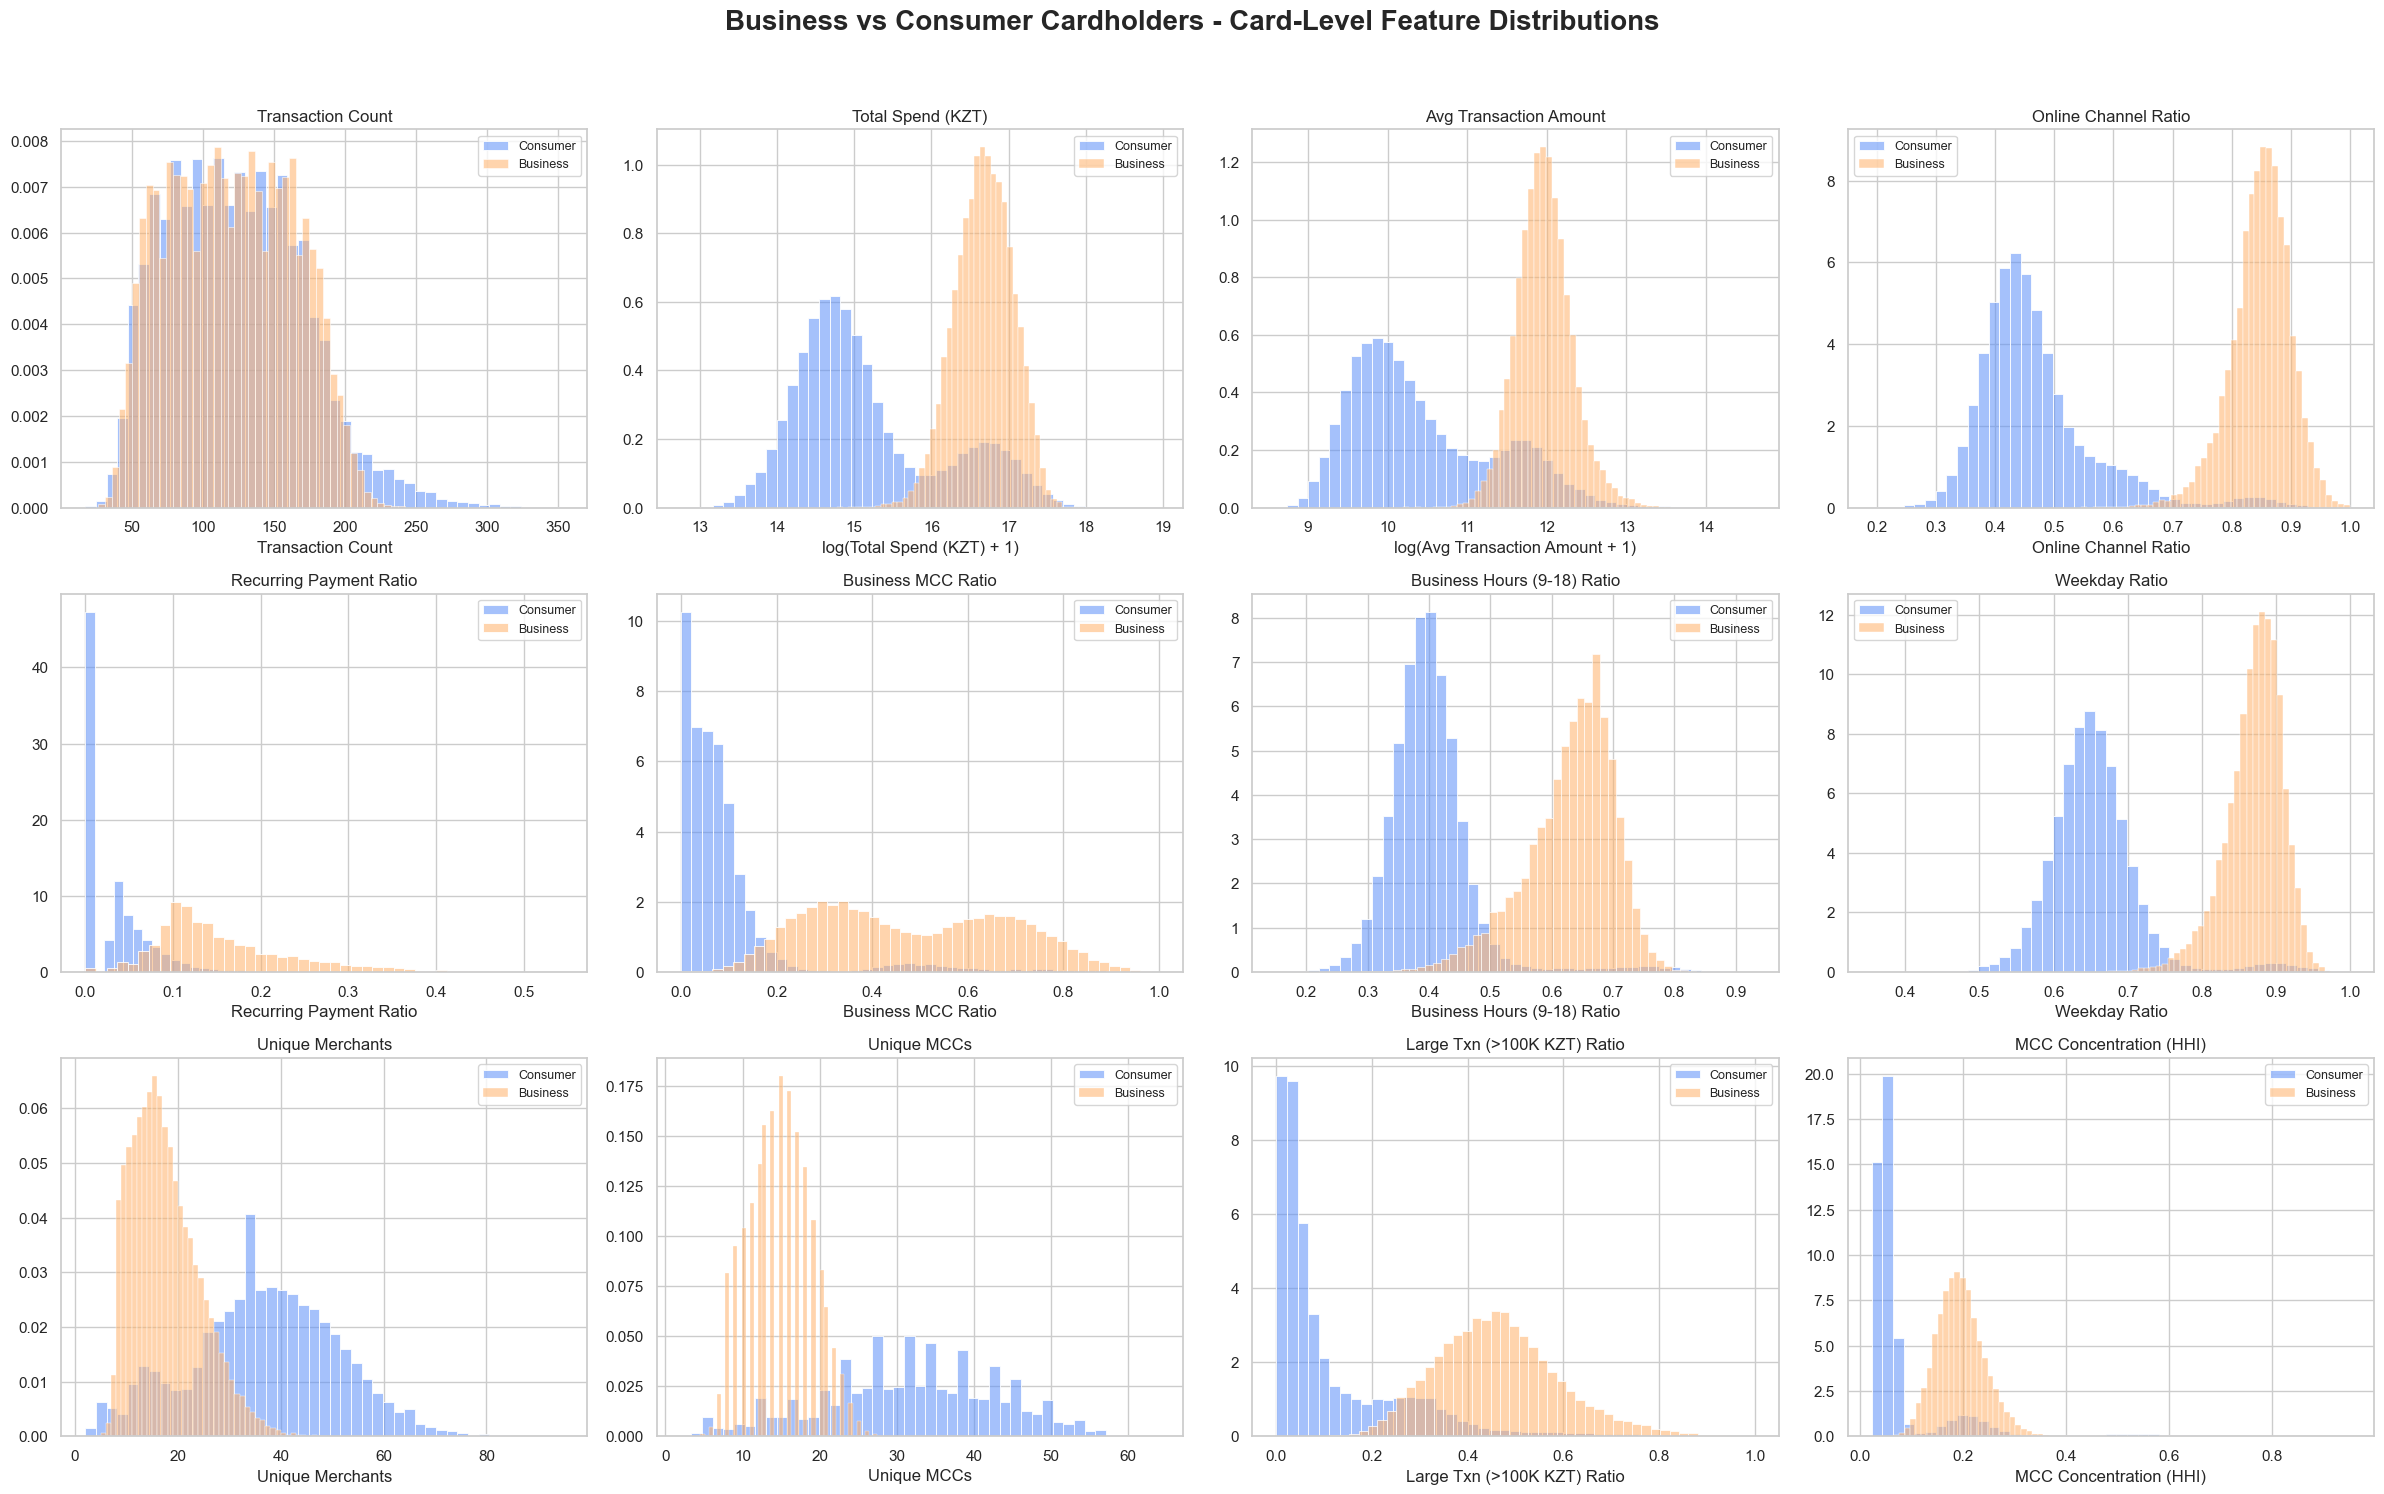

Saved to /Users/sapuantalaspay/vs_projects/data/EDA


In [38]:
plot_specs = [
    ("txn_count", "Transaction Count", False),
    ("total_spend", "Total Spend (KZT)", True),
    ("avg_amount", "Avg Transaction Amount", True),
    ("online_ratio", "Online Channel Ratio", False),
    ("recurring_ratio", "Recurring Payment Ratio", False),
    ("business_mcc_ratio", "Business MCC Ratio", False),
    ("business_hours_ratio", "Business Hours (9-18) Ratio", False),
    ("weekday_ratio", "Weekday Ratio", False),
    ("unique_merchants", "Unique Merchants", False),
    ("unique_mcc", "Unique MCCs", False),
    ("large_txn_100k_ratio", "Large Txn (>100K KZT) Ratio", False),
    ("mcc_hhi", "MCC Concentration (HHI)", False),
]

colors = {
    "Consumer": "#5B8FF9",
    "Business": "#FFB26B",
}

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
axes = axes.ravel()

for ax, (col, title, use_log) in zip(axes, plot_specs):
    for segment in ["Consumer", "Business"]:
        data = viz_df.loc[viz_df["segment"] == segment, col].dropna()

        if use_log:
            data = np.log1p(data)
            xlabel = f"log({title} + 1)"
        else:
            xlabel = title

        sns.histplot(
            data,
            bins=45,
            stat="density",
            alpha=0.55,
            color=colors[segment],
            label=segment,
            ax=ax,
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.legend(fontsize=9)

fig.suptitle(
    "Business vs Consumer Cardholders - Card-Level Feature Distributions",
    fontsize=20,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_PATH, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved to {FIG_PATH}")